# Tesla Deliveries Sales and Price ML Pipeline

This notebook builds an end-to-end machine learning pipeline on Tesla delivery, production, and price data. It covers preprocessing, EDA, feature engineering, regression modeling, hyperparameter tuning, and 12-month time-series forecasting.

## 1. Import Libraries

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNet, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from statsmodels.tsa.holtwinters import ExponentialSmoothing

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

DATA_PATH = Path('tesla_deliveries_dataset_2015_2025.csv')
OUTPUT_DIR = Path('outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

TARGET = 'Estimated_Deliveries'
RANDOM_STATE = 42

## 2. Load and Validate Data

In [2]:
df = pd.read_csv(DATA_PATH)

required_columns = {
    'Year', 'Month', 'Region', 'Model', TARGET, 'Production_Units',
    'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons',
    'Source_Type', 'Charging_Stations'
}
missing_columns = required_columns.difference(df.columns)
if missing_columns:
    raise ValueError(f'Missing required columns: {sorted(missing_columns)}')

df['Date'] = pd.to_datetime(df[['Year', 'Month']].assign(Day=1))
df = df.sort_values(['Date', 'Region', 'Model']).reset_index(drop=True)

print('Dataset shape:', df.shape)
display(df.head())

Dataset shape: (2640, 13)


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date
0,2015,1,Asia,Cybertruck,11325,11887,54449.08,60,339,575.88,Estimated (Region),6902,2015-01-01
1,2015,1,Asia,Model 3,8795,9165,87988.73,82,456,601.58,Official (Quarter),12626,2015-01-01
2,2015,1,Asia,Model S,9537,10093,68994.43,82,484,692.39,Official (Quarter),7281,2015-01-01
3,2015,1,Asia,Model X,7292,7298,107082.30,120,702,767.85,Estimated (Region),11748,2015-01-01
4,2015,1,Asia,Model Y,12446,13885,55183.13,60,340,634.75,Official (Quarter),4390,2015-01-01


In [3]:
display(df.info())
display(df.describe())
display(df.isna().sum().to_frame('missing_values'))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Year                  2640 non-null   int64         
 1   Month                 2640 non-null   int64         
 2   Region                2640 non-null   object        
 3   Model                 2640 non-null   object        
 4   Estimated_Deliveries  2640 non-null   int64         
 5   Production_Units      2640 non-null   int64         
 6   Avg_Price_USD         2640 non-null   float64       
 7   Battery_Capacity_kWh  2640 non-null   int64         
 8   Range_km              2640 non-null   int64         
 9   CO2_Saved_tons        2640 non-null   float64       
 10  Source_Type           2640 non-null   object        
 11  Charging_Stations     2640 non-null   int64         
 12  Date                  2640 non-null   datetime64[ns]
dtypes: datetime64[ns](

None

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations,Date
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712,2020-06-16 02:10:54.545454592
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000,2015-01-01 00:00:00
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000,2017-09-23 12:00:00
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000,2020-06-16 00:00:00
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000,2023-03-08 18:00:00
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000,2025-12-01 00:00:00
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883,NaN


,missing_values
Year,0
Month,0
Region,0
Model,0
Estimated_Deliveries,0
Production_Units,0
Avg_Price_USD,0
Battery_Capacity_kWh,0
Range_km,0
CO2_Saved_tons,0


## 3. Exploratory Data Analysis

In [4]:
monthly = (
    df.groupby('Date', as_index=False)
    .agg(
        Estimated_Deliveries=(TARGET, 'sum'),
        Production_Units=('Production_Units', 'sum'),
        Avg_Price_USD=('Avg_Price_USD', 'mean'),
        Charging_Stations=('Charging_Stations', 'mean')
    )
    .sort_values('Date')
)
monthly['YoY_Delivery_Growth'] = monthly['Estimated_Deliveries'].pct_change(12)
monthly.to_csv(OUTPUT_DIR / 'eda_monthly_deliveries.csv', index=False)

display(monthly.head())

,Date,Estimated_Deliveries,Production_Units,Avg_Price_USD,Charging_Stations,YoY_Delivery_Growth
0,2015-01-01,183180,195793,84502.4970,8277.70,NaN
1,2015-02-01,165053,176119,81745.5695,8861.80,NaN
2,2015-03-01,184567,200151,86221.2895,9198.20,NaN
3,2015-04-01,225623,241706,83446.1640,9471.25,NaN
4,2015-05-01,184264,198205,85632.1110,11694.40,NaN


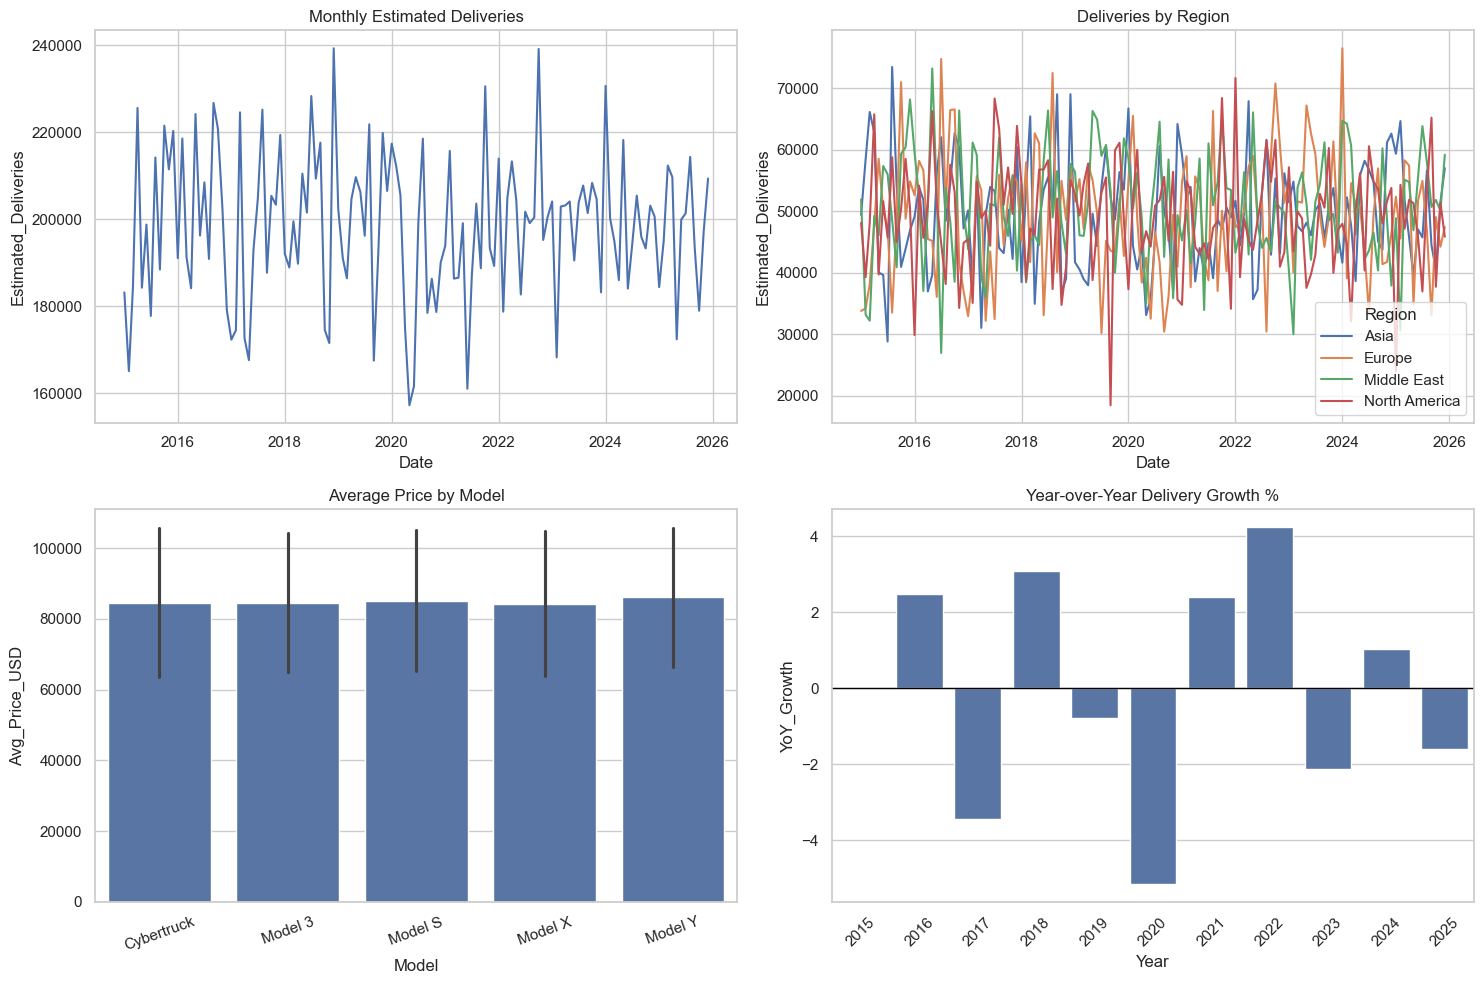

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.lineplot(data=monthly, x='Date', y='Estimated_Deliveries', ax=axes[0, 0])
axes[0, 0].set_title('Monthly Estimated Deliveries')

region_monthly = df.groupby(['Date', 'Region'], as_index=False)[TARGET].sum()
sns.lineplot(data=region_monthly, x='Date', y=TARGET, hue='Region', ax=axes[0, 1])
axes[0, 1].set_title('Deliveries by Region')

sns.barplot(data=df, x='Model', y='Avg_Price_USD', estimator='mean', errorbar='sd', ax=axes[1, 0])
axes[1, 0].set_title('Average Price by Model')
axes[1, 0].tick_params(axis='x', rotation=20)

yearly = df.groupby('Year', as_index=False)[TARGET].sum()
yearly['YoY_Growth'] = yearly[TARGET].pct_change() * 100
sns.barplot(data=yearly, x='Year', y='YoY_Growth', ax=axes[1, 1])
axes[1, 1].axhline(0, color='black', linewidth=1)
axes[1, 1].set_title('Year-over-Year Delivery Growth %')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

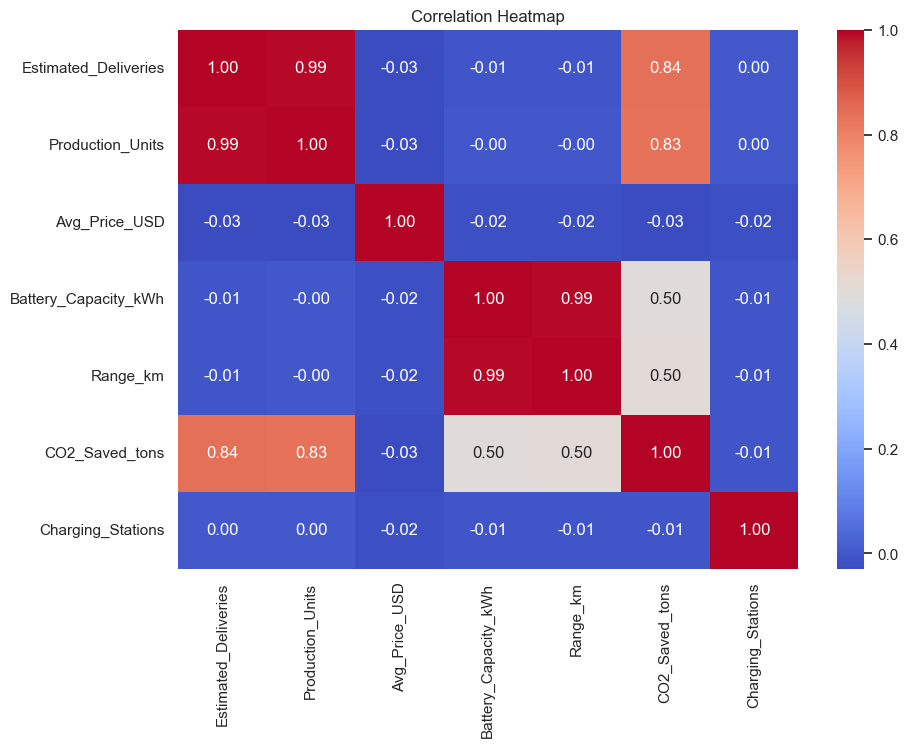

In [6]:
numeric_cols = [
    TARGET, 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh',
    'Range_km', 'CO2_Saved_tons', 'Charging_Stations'
]

plt.figure(figsize=(10, 7))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

## 4. Feature Engineering

In [7]:
def engineer_features(data):
    data = data.copy()
    data['Quarter'] = data['Date'].dt.quarter
    data['MonthSin'] = np.sin(2 * np.pi * data['Month'] / 12)
    data['MonthCos'] = np.cos(2 * np.pi * data['Month'] / 12)
    data['QuarterEnd'] = (data['Month'] % 3 == 0).astype(int)
    data['YearsSince2015'] = data['Year'] - 2015
    data['PricePerRange'] = data['Avg_Price_USD'] / data['Range_km'].replace(0, np.nan)

    group_cols = ['Region', 'Model']
    data = data.sort_values(group_cols + ['Date']).reset_index(drop=True)
    grouped = data.groupby(group_cols, group_keys=False)

    for lag in (1, 3, 6):
        data[f'DeliveriesLag{lag}'] = grouped[TARGET].shift(lag)
        data[f'PriceLag{lag}'] = grouped['Avg_Price_USD'].shift(lag)

    data['DeliveriesRolling3'] = grouped[TARGET].transform(
        lambda s: s.shift(1).rolling(3, min_periods=2).mean()
    )
    data['DeliveriesRolling6'] = grouped[TARGET].transform(
        lambda s: s.shift(1).rolling(6, min_periods=3).mean()
    )
    data['PriceRolling3'] = grouped['Avg_Price_USD'].transform(
        lambda s: s.shift(1).rolling(3, min_periods=2).mean()
    )

    return data.dropna().reset_index(drop=True)


ml_df = engineer_features(df)
print('ML-ready shape:', ml_df.shape)
display(ml_df.head())

ML-ready shape: (2520, 28)


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,...,PricePerRange,DeliveriesLag1,PriceLag1,DeliveriesLag3,PriceLag3,DeliveriesLag6,PriceLag6,DeliveriesRolling3,DeliveriesRolling6,PriceRolling3
0,2015,7,Asia,Cybertruck,113,118,115067.04,120,709,12.02,...,162.294838,7201.0,114461.07,15221.0,112686.63,11325.0,54449.08,9609.333333,10610.666667,111575.103333
1,2015,8,Asia,Cybertruck,10222,11128,77930.19,60,331,507.52,...,235.438640,113.0,115067.04,6406.0,107577.61,13254.0,88864.06,4573.333333,8742.000000,112368.573333
2,2015,9,Asia,Cybertruck,10844,12086,59807.92,60,356,579.07,...,167.999775,10222.0,77930.19,7201.0,114461.07,10257.0,65107.47,5845.333333,8236.666667,102486.100000
3,2015,10,Asia,Cybertruck,5675,6461,117974.08,120,716,609.49,...,164.768268,10844.0,59807.92,113.0,115067.04,15221.0,112686.63,7059.666667,8334.500000,84268.383333
4,2015,11,Asia,Cybertruck,4482,4968,84711.30,82,454,305.22,...,186.588767,5675.0,117974.08,10222.0,77930.19,6406.0,107577.61,8913.666667,6743.500000,85237.396667


The target is `Estimated_Deliveries`. Target-derived ratios such as deliveries per CO2 are intentionally excluded from the feature list to avoid leakage.

In [8]:
numeric_features = [
    'Year', 'Month', 'Quarter', 'MonthSin', 'MonthCos', 'QuarterEnd',
    'YearsSince2015', 'Production_Units', 'Avg_Price_USD',
    'Battery_Capacity_kWh', 'Range_km', 'Charging_Stations', 'PricePerRange',
    'DeliveriesLag1', 'DeliveriesLag3', 'DeliveriesLag6',
    'PriceLag1', 'PriceLag3', 'PriceLag6',
    'DeliveriesRolling3', 'DeliveriesRolling6', 'PriceRolling3'
]
categorical_features = ['Region', 'Model', 'Source_Type']
feature_cols = numeric_features + categorical_features

X = ml_df[feature_cols]
y = ml_df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, shuffle=True
)

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)

Train shape: (2016, 25)
Test shape: (504, 25)


## 5. Preprocessing Pipeline

In [9]:
numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features)
])

## 6. Train Regression Models

In [10]:
def evaluate_regression_model(name, estimator, X_eval, y_eval):
    predictions = np.maximum(estimator.predict(X_eval), 0)
    return {
        'Model': name,
        'MAE': mean_absolute_error(y_eval, predictions),
        'RMSE': np.sqrt(mean_squared_error(y_eval, predictions)),
        'R2': r2_score(y_eval, predictions),
        'Predictions': predictions,
        'Estimator': estimator
    }


models = {
    'Ridge': Ridge(alpha=10.0),
    'ElasticNet': ElasticNet(alpha=0.05, l1_ratio=0.2, max_iter=10000),
    'RandomForest': RandomForestRegressor(
        n_estimators=250,
        max_depth=12,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    'GradientBoosting': GradientBoostingRegressor(random_state=RANDOM_STATE)
}

results = []
for name, model in models.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    pipeline.fit(X_train, y_train)
    results.append(evaluate_regression_model(name, pipeline, X_test, y_test))

model_comparison = (
    pd.DataFrame([{k: v for k, v in row.items() if k not in ['Predictions', 'Estimator']} for row in results])
    .sort_values('MAE')
    .reset_index(drop=True)
)

display(model_comparison)

,Model,MAE,RMSE,R2
0,GradientBoosting,332.045104,414.927103,0.989110
1,Ridge,332.934507,415.481552,0.989081
2,RandomForest,336.625635,422.855705,0.988690
3,ElasticNet,361.811820,433.731179,0.988101


## 7. Hyperparameter Tuning

In [11]:
tuned_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', GradientBoostingRegressor(random_state=RANDOM_STATE))
])

param_grid = {
    'model__n_estimators': [150, 250],
    'model__learning_rate': [0.03, 0.06, 0.10],
    'model__max_depth': [2, 3],
    'model__min_samples_leaf': [1, 3]
}

ordered_train = X_train.sort_values(['Year', 'Month'])
ordered_target = y_train.loc[ordered_train.index]

grid_search = GridSearchCV(
    tuned_pipeline,
    param_grid=param_grid,
    scoring='neg_mean_absolute_error',
    cv=TimeSeriesSplit(n_splits=4),
    n_jobs=-1
)
grid_search.fit(ordered_train, ordered_target)

tuned_result = evaluate_regression_model(
    'GradientBoosting_Tuned', grid_search.best_estimator_, X_test, y_test
)
results.append(tuned_result)

model_comparison = (
    pd.DataFrame([{k: v for k, v in row.items() if k not in ['Predictions', 'Estimator']} for row in results])
    .sort_values('MAE')
    .reset_index(drop=True)
)

print('Best parameters:', grid_search.best_params_)
display(model_comparison)
model_comparison.to_csv(OUTPUT_DIR / 'model_comparison.csv', index=False)

Best parameters: {'model__learning_rate': 0.03, 'model__max_depth': 2, 'model__min_samples_leaf': 1, 'model__n_estimators': 250}


,Model,MAE,RMSE,R2
0,GradientBoosting,332.045104,414.927103,0.989110
1,GradientBoosting_Tuned,332.571950,412.045787,0.989261
2,Ridge,332.934507,415.481552,0.989081
3,RandomForest,336.625635,422.855705,0.988690
4,ElasticNet,361.811820,433.731179,0.988101


## 8. Best Model Diagnostics

Best model: GradientBoosting


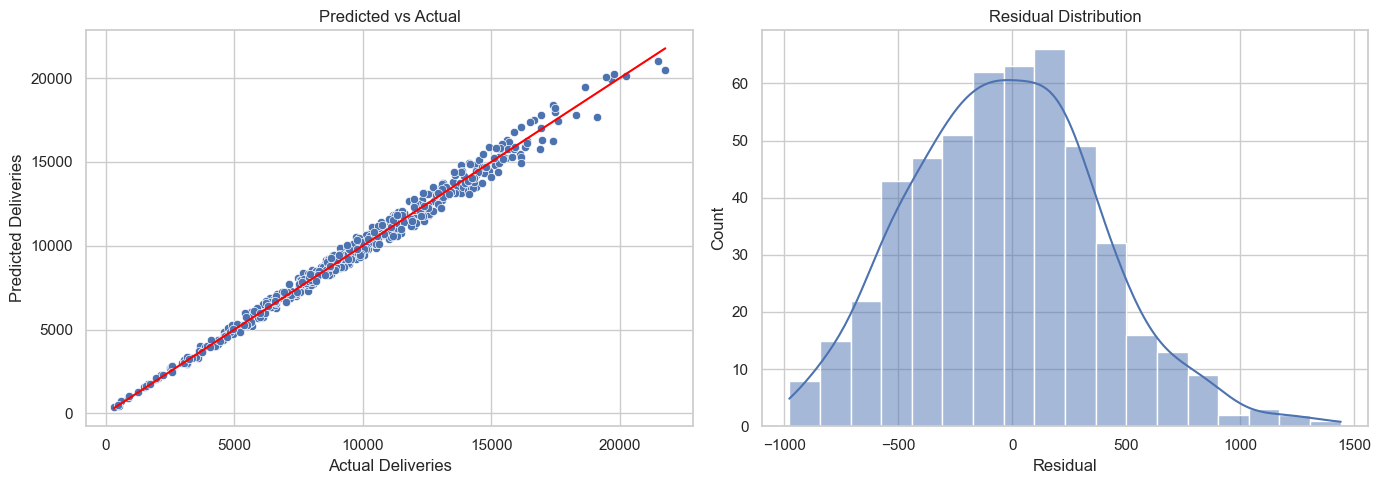

In [12]:
best_row = min(results, key=lambda row: row['MAE'])
best_model_name = best_row['Model']
best_predictions = best_row['Predictions']

print('Best model:', best_model_name)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(x=y_test, y=best_predictions, ax=axes[0])
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red')
axes[0].set_title('Predicted vs Actual')
axes[0].set_xlabel('Actual Deliveries')
axes[0].set_ylabel('Predicted Deliveries')

residuals = y_test - best_predictions
sns.histplot(residuals, kde=True, ax=axes[1])
axes[1].set_title('Residual Distribution')
axes[1].set_xlabel('Residual')

plt.tight_layout()
plt.show()

## 9. Time-Series Forecasting

In [13]:
ts = df.groupby('Date')[TARGET].sum().asfreq('MS')
train_ts = ts.iloc[:-12]
test_ts = ts.iloc[-12:]

hw_model = ExponentialSmoothing(
    train_ts,
    trend='add',
    seasonal='add',
    seasonal_periods=12
)
hw_fit = hw_model.fit(optimized=True)
test_forecast = hw_fit.forecast(12)

forecast_mae = mean_absolute_error(test_ts, test_forecast)
forecast_rmse = np.sqrt(mean_squared_error(test_ts, test_forecast))

print(f'Holt-Winters MAE: {forecast_mae:.2f}')
print(f'Holt-Winters RMSE: {forecast_rmse:.2f}')

Holt-Winters MAE: 10494.57
Holt-Winters RMSE: 13871.70


In [14]:
final_hw_model = ExponentialSmoothing(
    ts,
    trend='add',
    seasonal='add',
    seasonal_periods=12
)
final_hw_fit = final_hw_model.fit(optimized=True)
future_forecast = final_hw_fit.forecast(12)

forecast_df = pd.DataFrame({
    'Date': future_forecast.index,
    'Forecast_Deliveries': future_forecast.round().astype(int)
})

forecast_df.to_csv(OUTPUT_DIR / 'forecast_12_months.csv', index=False)
display(forecast_df)

,Date,Forecast_Deliveries
2026-01-01,2026-01-01,192503
2026-02-01,2026-02-01,190434
2026-03-01,2026-03-01,198070
2026-04-01,2026-04-01,189793
2026-05-01,2026-05-01,197736
2026-06-01,2026-06-01,192219
2026-07-01,2026-07-01,201205
2026-08-01,2026-08-01,208205
2026-09-01,2026-09-01,198374
2026-10-01,2026-10-01,203016


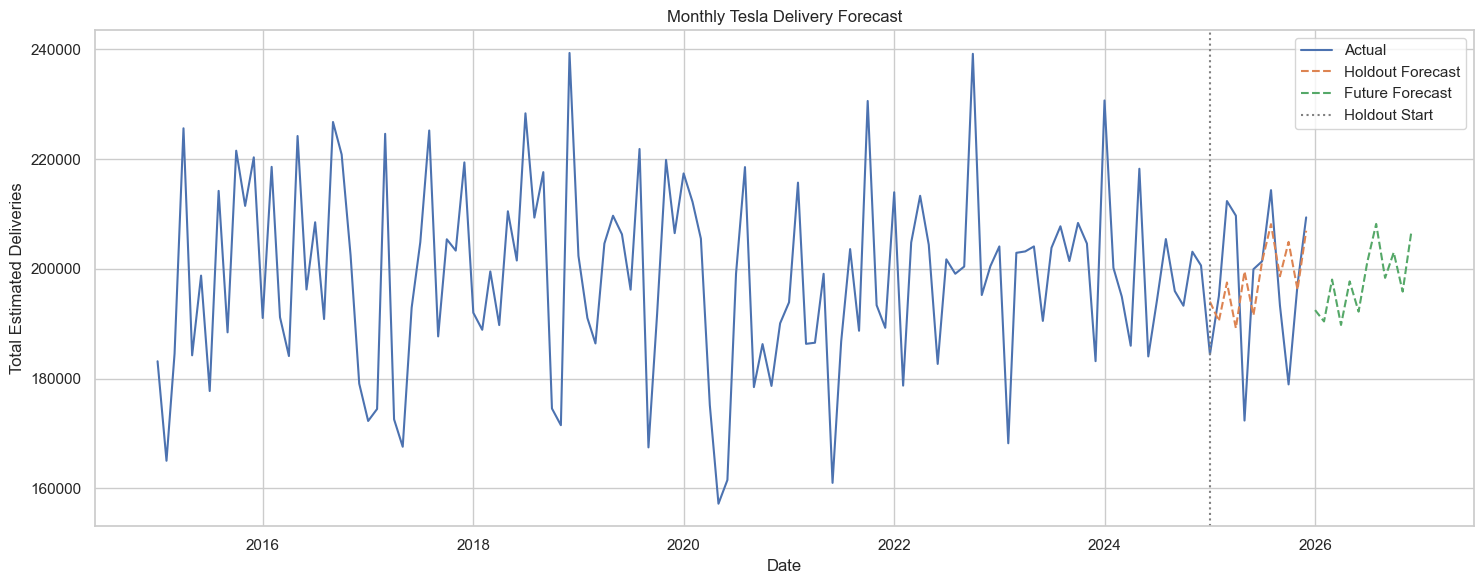

In [15]:
plt.figure(figsize=(15, 6))
plt.plot(ts.index, ts.values, label='Actual')
plt.plot(test_ts.index, test_forecast.values, label='Holdout Forecast', linestyle='--')
plt.plot(forecast_df['Date'], forecast_df['Forecast_Deliveries'], label='Future Forecast', linestyle='--')
plt.axvline(test_ts.index[0], color='gray', linestyle=':', label='Holdout Start')
plt.title('Monthly Tesla Delivery Forecast')
plt.xlabel('Date')
plt.ylabel('Total Estimated Deliveries')
plt.legend()
plt.tight_layout()
plt.show()

## 10. Final Summary

In [16]:
print('Dataset shape:', df.shape)
print('ML-ready shape:', ml_df.shape)
print('\nModel comparison:')
print(model_comparison.to_string(index=False, formatters={
    'MAE': '{:.2f}'.format,
    'RMSE': '{:.2f}'.format,
    'R2': '{:.4f}'.format
}))
print(f'\nBest model: {best_model_name}')
print('\n12-month forecast:')
print(forecast_df.to_string(index=False))

Dataset shape: (2640, 13)
ML-ready shape: (2520, 28)

Model comparison:
                 Model    MAE   RMSE     R2
      GradientBoosting 332.05 414.93 0.9891
GradientBoosting_Tuned 332.57 412.05 0.9893
                 Ridge 332.93 415.48 0.9891
          RandomForest 336.63 422.86 0.9887
            ElasticNet 361.81 433.73 0.9881

Best model: GradientBoosting

12-month forecast:
      Date  Forecast_Deliveries
2026-01-01               192503
2026-02-01               190434
2026-03-01               198070
2026-04-01               189793
2026-05-01               197736
2026-06-01               192219
2026-07-01               201205
2026-08-01               208205
2026-09-01               198374
2026-10-01               203016
2026-11-01               195870
2026-12-01               206738
